# Numerical Linear Algebra — Notebook 1: Fundamentals

**Topics covered:** Matrix Multiplication · Orthogonal Vectors and Matrices · Norms · Singular Value Decomposition

**Audience:** PhD students in mathematics, applied mathematics, and computational sciences.

**References:**
- Trefethen & Bau, *Numerical Linear Algebra* (SIAM, 1997)
- Golub & Van Loan, *Matrix Computations* (Johns Hopkins, 4th ed., 2013)


In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import time

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})


---
## 1. Matrix Multiplication

### Motivation

Matrix multiplication underlies every algorithm in numerical linear algebra.
Its algebraic structure determines computational cost; its geometric interpretation explains
why composition of linear maps is associative; its block formulation drives modern hardware performance.

### Definition

For $A \in \mathbb{R}^{m \times k}$ and $B \in \mathbb{R}^{k \times n}$, the product
$C = AB \in \mathbb{R}^{m \times n}$ is:

$$c_{ij} = \sum_{\ell=1}^{k} a_{i\ell}\, b_{\ell j}, \qquad 1 \le i \le m,\; 1 \le j \le n.$$

### Three Equivalent Interpretations

**1. Inner product view** — $c_{ij}$ is the dot product of row $i$ of $A$ with column $j$ of $B$.

**2. Column view** — each column $c_j = A b_j$ is a linear combination of columns of $A$.

**3. Outer product (rank-1) view** — the sum of $k$ rank-1 matrices:

$$AB = \sum_{\ell=1}^{k} a_{:\ell}\, b_{\ell:}^{\top}.$$

The outer product view is computationally fundamental: it reveals that $C$ is a sum of $k$ rank-1
contributions. This structure is exploited in randomized linear algebra and streaming algorithms.

### Algebraic Properties

- Associativity: $(AB)C = A(BC)$
- Distributivity: $A(B + C) = AB + AC$
- Not commutative: $AB \neq BA$ in general
- Transpose reversal: $(AB)^{\top} = B^{\top} A^{\top}$
- Inverse reversal: $(AB)^{-1} = B^{-1}A^{-1}$ when both inverses exist

### Computational Cost

For $A \in \mathbb{R}^{m \times k}$, $B \in \mathbb{R}^{k \times n}$:
approximately $2mnk$ flops. For square $n \times n$ matrices: $O(n^3)$.

Strassen's algorithm achieves $O(n^{2.807})$, but with large constants and worse numerical properties.
In practice, highly optimized BLAS level-3 routines (used by NumPy/LAPACK) dominate completely.


In [2]:
def matmul_naive(A, B):
    'Triple-loop matrix multiplication, directly from the definition.'
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, "Inner dimensions must agree."
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for ell in range(k):
                C[i, j] += A[i, ell] * B[ell, j]
    return C

def matmul_outer(A, B):
    'Matrix multiplication as a sum of outer (rank-1) products.'
    m, k = A.shape
    _, n = B.shape
    C = np.zeros((m, n))
    for ell in range(k):
        C += np.outer(A[:, ell], B[ell, :])
    return C

# Correctness check
A = np.random.randn(5, 6)
B = np.random.randn(6, 4)
C_ref = A @ B

print("Correctness verification:")
print(f"  Naive triple loop  error: {np.max(np.abs(matmul_naive(A, B) - C_ref)):.2e}")
print(f"  Outer product sum  error: {np.max(np.abs(matmul_outer(A, B) - C_ref)):.2e}")


Correctness verification:
  Naive triple loop  error: 4.44e-16
  Outer product sum  error: 4.44e-16


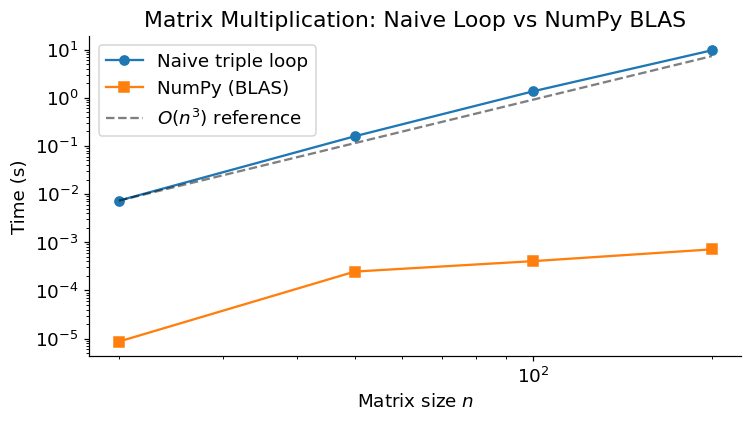

Speedup factors (naive / NumPy):
  n =  20:     843.9x
  n =  50:     645.5x
  n = 100:    3366.3x
  n = 200:   13572.6x


In [3]:
# Timing comparison across matrix sizes
sizes = [20, 50, 100, 200]
t_naive, t_numpy = [], []

for n in sizes:
    A = np.random.randn(n, n)
    B = np.random.randn(n, n)

    t0 = time.perf_counter()
    matmul_naive(A, B)
    t_naive.append(time.perf_counter() - t0)

    # Warm up cache, then time
    _ = A @ B
    t0 = time.perf_counter()
    for _ in range(20):
        A @ B
    t_numpy.append((time.perf_counter() - t0) / 20)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(sizes, t_naive, 'o-', label='Naive triple loop')
ax.loglog(sizes, t_numpy, 's-', label='NumPy (BLAS)')
ref = [t_naive[0] * (n / sizes[0])**3 for n in sizes]
ax.loglog(sizes, ref, 'k--', alpha=0.5, label=r'$O(n^3)$ reference')
ax.set_xlabel('Matrix size $n$')
ax.set_ylabel('Time (s)')
ax.set_title('Matrix Multiplication: Naive Loop vs NumPy BLAS')
ax.legend()
plt.tight_layout()
plt.show()

print("Speedup factors (naive / NumPy):")
for n, tn, tl in zip(sizes, t_numpy, t_naive):
    print(f"  n = {n:3d}:  {tl/tn:8.1f}x")


### Block Matrix Multiplication

For $A$ and $B$ partitioned conformably into blocks, the product $C = AB$ satisfies:

$$C_{ij} = \sum_k A_{ik} B_{kj},$$

exactly as for scalar entries. Block multiplication is algebraically identical to standard multiplication.

It matters computationally because cache efficiency depends on memory access patterns.
BLAS level-3 routines partition matrices into blocks sized to fit in L2/L3 cache,
achieving near-peak arithmetic throughput on modern hardware.

**Numerical insight:** The speed gap between a naive loop and NumPy is not algorithmic complexity
($O(n^3)$ in both cases) but memory hierarchy. BLAS exploits spatial and temporal locality
to keep data in fast cache as long as possible.


In [4]:
def matmul_blocked(A, B, bs):
    'Block matrix multiplication with block size bs.'
    m, k = A.shape
    _, n = B.shape
    C = np.zeros((m, n))
    for i in range(0, m, bs):
        for j in range(0, n, bs):
            for l in range(0, k, bs):
                C[i:i+bs, j:j+bs] += A[i:i+bs, l:l+bs] @ B[l:l+bs, j:j+bs]
    return C

n = 200
A = np.random.randn(n, n)
B = np.random.randn(n, n)
C_ref = A @ B

for bs in [10, 25, 50, 100]:
    err = np.max(np.abs(matmul_blocked(A, B, bs) - C_ref))
    print(f"Block size {bs:3d}: max error = {err:.2e}")


Block size  10: max error = 5.68e-14
Block size  25: max error = 7.11e-14
Block size  50: max error = 6.39e-14
Block size 100: max error = 6.39e-14


---
## 2. Orthogonal Vectors and Matrices

### Motivation

Orthogonality is the organizing principle of stable numerical algorithms.
An orthogonal transformation maps the unit sphere to itself: it rotates or reflects without stretching.
This norm-preserving property prevents error amplification, which is why Householder, Givens,
and QR-based methods dominate computational practice.

### Definitions

**Inner product:** For $u, v \in \mathbb{R}^n$: $\langle u, v \rangle = u^{\top} v = \sum_{i=1}^n u_i v_i$.

**Orthogonality:** $u \perp v$ iff $u^{\top} v = 0$.

**Orthonormal set:** $\{q_1, \ldots, q_k\}$ satisfies $q_i^{\top} q_j = \delta_{ij}$.

**Orthogonal matrix:** $Q \in \mathbb{R}^{n \times n}$ satisfies

$$Q^{\top} Q = Q Q^{\top} = I_n \quad \Longleftrightarrow \quad Q^{-1} = Q^{\top}.$$

The columns of $Q$ form an orthonormal basis of $\mathbb{R}^n$; so do the rows.

### Key Properties

| Property | Formula |
|---|---|
| Norm preservation | $\|Qx\|_2 = \|x\|_2$ for all $x$ |
| Inner product preservation | $\langle Qu, Qv \rangle = \langle u, v \rangle$ |
| Determinant | $\det(Q) = \pm 1$ |
| Eigenvalues | $|\lambda_i| = 1$ for all $i$ |
| Group closure | $Q_1 Q_2$ orthogonal if $Q_1, Q_2$ orthogonal |

### Standard Examples

**Rotation in $\mathbb{R}^2$:**

$$Q_\theta = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}, \quad \det(Q_\theta) = +1.$$

**Householder reflector** (reflection across hyperplane $\{v\}^\perp$):

$$H = I - 2vv^{\top}, \quad \|v\|_2 = 1, \quad \det(H) = -1.$$


In [5]:
# Verify the fundamental properties of an orthogonal matrix
n = 8
Q, _ = np.linalg.qr(np.random.randn(n, n))

print("Properties of a random orthogonal matrix (n=8):")
print(f"  ||Q^T Q - I||_F  = {np.linalg.norm(Q.T @ Q - np.eye(n), 'fro'):.2e}")
print(f"  ||Q Q^T - I||_F  = {np.linalg.norm(Q @ Q.T - np.eye(n), 'fro'):.2e}")
print(f"  det(Q)           = {np.linalg.det(Q):.8f}  (should be +/-1)")

x = np.random.randn(n)
y = np.random.randn(n)
print(f"  ||Qx||_2 / ||x||_2 = {np.linalg.norm(Q @ x) / np.linalg.norm(x):.10f}")
print(f"  <Qu, Qv> - <u,v>   = {(Q@x)@(Q@y) - x@y:.2e}")

# Eigenvalues lie on the unit circle
eigvals = np.linalg.eigvals(Q)
print(f"  max |lambda| deviation from 1: {max(abs(abs(eigvals) - 1)):.2e}")


Properties of a random orthogonal matrix (n=8):
  ||Q^T Q - I||_F  = 1.98e-15
  ||Q Q^T - I||_F  = 1.92e-15
  det(Q)           = -1.00000000  (should be +/-1)
  ||Qx||_2 / ||x||_2 = 1.0000000000
  <Qu, Qv> - <u,v>   = -2.66e-15
  max |lambda| deviation from 1: 4.44e-16


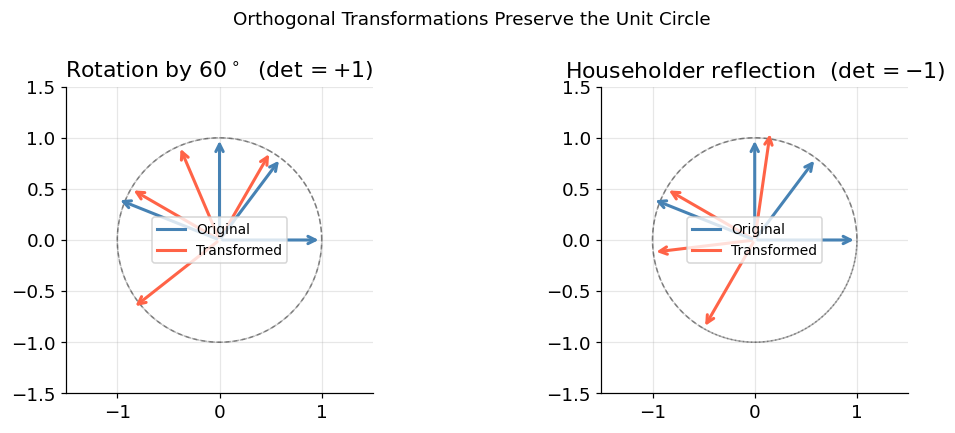

In [6]:
# Geometric visualization: rotation and reflection preserve the unit circle
theta = np.pi / 3

Q_rot = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])

v_ref = np.array([np.cos(np.pi/6), np.sin(np.pi/6)])
H_ref = np.eye(2) - 2 * np.outer(v_ref, v_ref)

# Unit circle
t = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(t), np.sin(t)])

# Test vectors
vecs = np.array([[1, 0], [0, 1], [0.6, 0.8], [-1, 0.4]]).T

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
configs = [(Q_rot, r'Rotation by $60^\circ$  ($\det = +1$)'),
           (H_ref, r'Householder reflection  ($\det = -1$)')]

for ax, (Q, title) in zip(axes, configs):
    ax.plot(*circle, 'k--', alpha=0.3, lw=1)
    ax.plot(*(Q @ circle), 'k--', alpha=0.3, lw=1)
    for col in range(vecs.shape[1]):
        u = vecs[:, col]
        Qu = Q @ u
        ax.annotate('', xy=u,   xytext=[0,0], arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
        ax.annotate('', xy=Qu, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='tomato',    lw=2))
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_title(title)
    ax.plot([], [], 'steelblue', lw=2, label='Original')
    ax.plot([], [], 'tomato', lw=2, label='Transformed')
    ax.legend(fontsize=9)

plt.suptitle('Orthogonal Transformations Preserve the Unit Circle', fontsize=12)
plt.tight_layout()
plt.show()


### Common Pitfall

A matrix with **approximately** orthonormal columns is not the same as a truly orthogonal matrix.
Classical Gram-Schmidt on nearly linearly dependent vectors produces columns that lose orthogonality
due to cancellation. The deviation $\|Q^{\top}Q - I\|$ is a direct measure of the loss of orthogonality,
and it can grow to $O(1)$ in the worst case.

This pitfall is central to the comparison of Gram-Schmidt variants in Notebook 2.


---
## 3. Norms

### Motivation

Norms give Euclidean and non-Euclidean geometry to vector spaces.
In numerical algorithms, norms measure errors, residuals, and convergence.
The choice of norm is not cosmetic: it affects which algorithms are natural and what bounds are tight.

### Vector Norms

A function $\|\cdot\| : \mathbb{R}^n \to \mathbb{R}_{\ge 0}$ is a **norm** if:

1. $\|x\| \ge 0$ and $\|x\| = 0 \Leftrightarrow x = 0$
2. $\|\alpha x\| = |\alpha|\|x\|$  (positive homogeneity)
3. $\|x + y\| \le \|x\| + \|y\|$  (triangle inequality)

The $p$-norms for $p \ge 1$:

$$\|x\|_p = \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}, \qquad
\|x\|_\infty = \max_{1 \le i \le n} |x_i|.$$

### Induced Matrix Norms

The **induced** (operator) norm subordinate to the vector norm $\|\cdot\|$ is:

$$\|A\| = \sup_{\|x\|=1} \|Ax\|.$$

This is the maximum factor by which $A$ stretches any unit vector.

Explicit formulas for $A \in \mathbb{R}^{m \times n}$:

$$\|A\|_1 = \max_j \sum_i |a_{ij}| \quad \text{(max absolute column sum)}$$

$$\|A\|_2 = \sigma_{\max}(A) \quad \text{(largest singular value)}$$

$$\|A\|_\infty = \max_i \sum_j |a_{ij}| \quad \text{(max absolute row sum)}$$

### Frobenius Norm

$$\|A\|_F = \left(\sum_{i,j} a_{ij}^2\right)^{1/2} = \left(\operatorname{tr}(A^{\top}A)\right)^{1/2} = \left(\sum_i \sigma_i^2\right)^{1/2}.$$

The Frobenius norm is not induced, but it satisfies $\|A\|_2 \le \|A\|_F \le \sqrt{r}\|A\|_2$ where $r = \operatorname{rank}(A)$.

### Norm Equivalence in $\mathbb{R}^n$

All norms are equivalent. Key inequalities for $x \in \mathbb{R}^n$:

$$\|x\|_2 \le \|x\|_1 \le \sqrt{n}\|x\|_2, \qquad \|x\|_\infty \le \|x\|_2 \le \sqrt{n}\|x\|_\infty.$$


In [7]:
# Vector norm computations
x = np.array([3., -4., 0., 2., -1., 5.])
n = len(x)

norms_v = {
    r'$\|x\|_1$':      np.linalg.norm(x, 1),
    r'$\|x\|_2$':      np.linalg.norm(x, 2),
    r'$\|x\|_\infty$': np.linalg.norm(x, np.inf),
}
print("Vector norms for x =", x)
for name, val in norms_v.items():
    print(f"  {name}: {val:.6f}")

l1, l2, linf = norms_v.values()
print(f"\nEquivalence bounds (n = {n}):")
print(f"  ||x||_2 <= ||x||_1:           {l2:.4f} <= {l1:.4f}   {'OK' if l2<=l1+1e-12 else 'FAIL'}")
print(f"  ||x||_1 <= sqrt(n)*||x||_2:   {l1:.4f} <= {np.sqrt(n)*l2:.4f}   {'OK' if l1<=np.sqrt(n)*l2+1e-12 else 'FAIL'}")
print(f"  ||x||_inf <= ||x||_2:         {linf:.4f} <= {l2:.4f}   {'OK' if linf<=l2+1e-12 else 'FAIL'}")
print(f"  ||x||_2 <= sqrt(n)*||x||_inf: {l2:.4f} <= {np.sqrt(n)*linf:.4f}   {'OK' if l2<=np.sqrt(n)*linf+1e-12 else 'FAIL'}")


Vector norms for x = [ 3. -4.  0.  2. -1.  5.]
  $\|x\|_1$: 15.000000
  $\|x\|_2$: 7.416198
  $\|x\|_\infty$: 5.000000

Equivalence bounds (n = 6):
  ||x||_2 <= ||x||_1:           7.4162 <= 15.0000   OK
  ||x||_1 <= sqrt(n)*||x||_2:   15.0000 <= 18.1659   OK
  ||x||_inf <= ||x||_2:         5.0000 <= 7.4162   OK
  ||x||_2 <= sqrt(n)*||x||_inf: 7.4162 <= 12.2474   OK


In [8]:
# Matrix norms
A = np.array([[ 1., -3.,  2.],
              [-4.,  5., -1.],
              [ 2., -2.,  6.]])

print("Matrix norms for A:")
print(f"  Induced 1-norm  (max col sum):  {np.linalg.norm(A, 1):.6f}")
print(f"  Induced 2-norm  (sigma_max):    {np.linalg.norm(A, 2):.6f}")
print(f"  Induced inf-norm (max row sum): {np.linalg.norm(A, np.inf):.6f}")
print(f"  Frobenius norm:                 {np.linalg.norm(A, 'fro'):.6f}")

# Cross-verify via SVD
sv = np.linalg.svd(A, compute_uv=False)
print(f"\n  2-norm via SVD:        sigma_max = {sv[0]:.6f}")
print(f"  Frobenius via SVD: sqrt(sum sv^2) = {np.linalg.norm(sv):.6f}")


Matrix norms for A:
  Induced 1-norm  (max col sum):  10.000000
  Induced 2-norm  (sigma_max):    8.932211
  Induced inf-norm (max row sum): 10.000000
  Frobenius norm:                 10.000000

  2-norm via SVD:        sigma_max = 8.932211
  Frobenius via SVD: sqrt(sum sv^2) = 10.000000


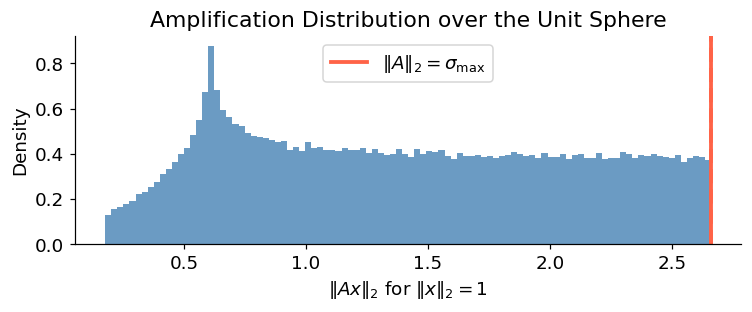

||A||_2 from np.linalg.norm:    2.65942893
||A||_2 from max sample:        2.65942887
||A||_2 from v_1 direction:     2.65942893


In [9]:
# The 2-norm as maximum amplification: visual demonstration
np.random.seed(3)
A = np.random.randn(3, 3)
A_norm2 = np.linalg.norm(A, 2)

# Sample unit vectors uniformly and measure amplification
N = 200_000
X = np.random.randn(3, N)
X /= np.linalg.norm(X, axis=0)         # project onto unit sphere
amp = np.linalg.norm(A @ X, axis=0)    # amplification for each direction

# The direction achieving the maximum is the first right singular vector
U, s, Vt = np.linalg.svd(A)
v1 = Vt[0]                             # first right singular vector
amp_v1 = np.linalg.norm(A @ v1)

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(amp, bins=100, density=True, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(A_norm2, color='tomato', lw=2.5, label=r'$\|A\|_2 = \sigma_{\max}$')
ax.axvline(amp_v1,  color='tomato', lw=2.5, ls='--')
ax.set_xlabel(r'$\|Ax\|_2$ for $\|x\|_2 = 1$')
ax.set_ylabel('Density')
ax.set_title(r'Amplification Distribution over the Unit Sphere')
ax.legend()
plt.tight_layout()
plt.show()

print(f"||A||_2 from np.linalg.norm:    {A_norm2:.8f}")
print(f"||A||_2 from max sample:        {amp.max():.8f}")
print(f"||A||_2 from v_1 direction:     {amp_v1:.8f}")


### Numerical Insight

The 2-norm is the natural norm for error analysis because $\|A\|_2 = \sigma_{\max}(A)$
connects directly to the SVD and to condition numbers.
The Frobenius norm is cheaper to compute and useful for convergence analysis in iterative methods.

Do not use the Frobenius norm in operator inequalities like $\|Ax\|_2 \le \|A\|_2 \|x\|_2$
and expect tight bounds — the Frobenius norm overestimates the induced 2-norm by up to $\sqrt{r}$.


---
## 4. Singular Value Decomposition (SVD)

### Motivation

The SVD is the complete diagonalization of an arbitrary rectangular matrix via orthogonal transformations.
It simultaneously reveals rank, norm, conditioning, and the best low-rank approximation.
Every other factorization (QR, Cholesky, Schur) can be understood as a partial or specialized SVD.

### Theorem (SVD)

Every $A \in \mathbb{R}^{m \times n}$ (with $m \ge n$) has a factorization:

$$A = U \Sigma V^{\top}$$

where $U \in \mathbb{R}^{m \times m}$ is orthogonal, $V \in \mathbb{R}^{n \times n}$ is orthogonal, and

$$\Sigma = \operatorname{diag}(\sigma_1, \ldots, \sigma_n) \in \mathbb{R}^{m \times n}, \quad \sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_n \ge 0.$$

The $\sigma_i$ are the **singular values** of $A$; the columns $u_i$ of $U$ are **left singular vectors**;
the columns $v_i$ of $V$ are **right singular vectors**.

The **thin (economy) SVD** is $A = \hat{U} \hat{\Sigma} V^{\top}$ with $\hat{U} \in \mathbb{R}^{m \times n}$.

### Fundamental Properties

| Property | Formula |
|---|---|
| Rank | $\operatorname{rank}(A) = $ number of positive $\sigma_i$ |
| 2-norm | $\|A\|_2 = \sigma_1$ |
| Frobenius norm | $\|A\|_F = (\sigma_1^2 + \cdots + \sigma_n^2)^{1/2}$ |
| Pseudoinverse | $A^+ = V \Sigma^+ U^{\top}$, $\Sigma^+ = \operatorname{diag}(1/\sigma_1, \ldots, 1/\sigma_r, 0, \ldots)$ |
| Outer product expansion | $A = \sum_{i=1}^{n} \sigma_i u_i v_i^{\top}$ |

### Best Rank-$k$ Approximation (Eckart-Young-Mirsky Theorem)

$$\min_{\operatorname{rank}(B) \le k} \|A - B\|_2 = \sigma_{k+1}, \quad
\text{achieved by } A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^{\top}.$$

This result holds for both the 2-norm and the Frobenius norm.


In [10]:
# Full SVD: computation and verification
np.random.seed(7)
m, n = 8, 5
A = np.random.randn(m, n)

U, s, Vt = np.linalg.svd(A, full_matrices=True)
V = Vt.T
Sigma = np.zeros((m, n))
np.fill_diagonal(Sigma, s)

print(f"A is {m} x {n}")
print(f"U is {U.shape}, V is {V.shape}")
print(f"Singular values: {s}")
print()
print(f"||U^T U - I||_F = {np.linalg.norm(U.T @ U - np.eye(m), 'fro'):.2e}")
print(f"||V^T V - I||_F = {np.linalg.norm(V.T @ V - np.eye(n), 'fro'):.2e}")
print(f"||U Sigma V^T - A||_F = {np.linalg.norm(U @ Sigma @ Vt - A, 'fro'):.2e}")
print()
print(f"||A||_2 = {np.linalg.norm(A, 2):.8f}  vs  sigma_1 = {s[0]:.8f}")
print(f"||A||_F = {np.linalg.norm(A, 'fro'):.8f}  vs  sqrt(sum sv^2) = {np.linalg.norm(s):.8f}")


A is 8 x 5
U is (8, 8), V is (5, 5)
Singular values: [4.30449059 3.44090014 2.93368874 2.43378545 1.05474652]

||U^T U - I||_F = 1.47e-15
||V^T V - I||_F = 1.21e-15
||U Sigma V^T - A||_F = 9.16e-15

||A||_2 = 4.30449059  vs  sigma_1 = 4.30449059
||A||_F = 6.78312350  vs  sqrt(sum sv^2) = 6.78312350


In [11]:
# Outer product (dyadic) expansion: rank-1 summation
U_hat = U[:, :n]  # thin left factor
print("Outer product reconstruction -- cumulative errors:")
A_approx = np.zeros((m, n))
for i in range(n):
    A_approx = A_approx + s[i] * np.outer(U_hat[:, i], V[:, i])
    next_sv = s[i+1] if (i+1) < n else 0.0
    print(f"  After rank-{i+1} term: ||A - A_k||_F = {np.linalg.norm(A - A_approx, 'fro'):.6f}"
          f"  (should match sigma_{i+2} = {next_sv:.6f})")


Outer product reconstruction -- cumulative errors:
  After rank-1 term: ||A - A_k||_F = 5.242340  (should match sigma_2 = 3.440900)
  After rank-2 term: ||A - A_k||_F = 3.955039  (should match sigma_3 = 2.933689)
  After rank-3 term: ||A - A_k||_F = 2.652509  (should match sigma_4 = 2.433785)
  After rank-4 term: ||A - A_k||_F = 1.054747  (should match sigma_5 = 1.054747)
  After rank-5 term: ||A - A_k||_F = 0.000000  (should match sigma_6 = 0.000000)


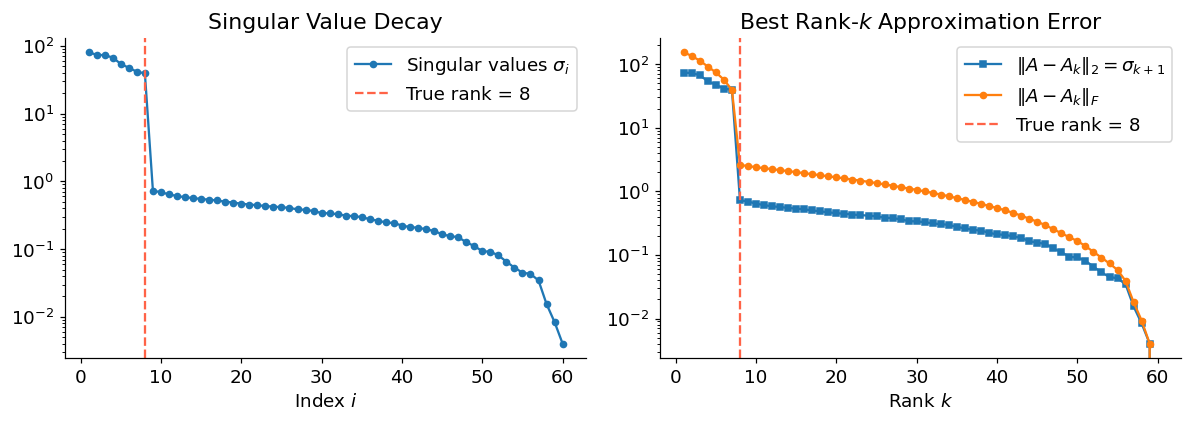

In [12]:
# Eckart-Young bound on a structured matrix
np.random.seed(11)
m, n = 60, 60
rank_true = 8
L = np.random.randn(m, rank_true)
R = np.random.randn(rank_true, n)
A = L @ R + 0.05 * np.random.randn(m, n)

U, s, Vt = np.linalg.svd(A)

errors_2   = []   # ||A - A_k||_2  = sigma_{k+1}
errors_fro = []   # ||A - A_k||_F  = sqrt(sum_{i>k} sigma_i^2)

A_k = np.zeros((m, n))
for k in range(n):
    A_k = A_k + s[k] * np.outer(U[:, k], Vt[k, :])
    errors_2.append(s[k+1] if k+1 < n else 0.0)
    errors_fro.append(np.sqrt(np.sum(s[k+1:]**2)))

ks = np.arange(1, n+1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(ks, s, 'o-', ms=4, lw=1.5, label='Singular values $\sigma_i$')
axes[0].axvline(rank_true, ls='--', color='tomato', lw=1.5, label=f'True rank = {rank_true}')
axes[0].set_xlabel('Index $i$')
axes[0].set_title('Singular Value Decay')
axes[0].legend()

axes[1].semilogy(ks, errors_2,   's-', ms=4, lw=1.5, label=r'$\|A - A_k\|_2 = \sigma_{k+1}$')
axes[1].semilogy(ks, errors_fro, 'o-', ms=4, lw=1.5, label=r'$\|A - A_k\|_F$')
axes[1].axvline(rank_true, ls='--', color='tomato', lw=1.5, label=f'True rank = {rank_true}')
axes[1].set_xlabel('Rank $k$')
axes[1].set_title('Best Rank-$k$ Approximation Error')
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
# Pseudoinverse via SVD and its four Moore-Penrose properties
np.random.seed(4)
m, n = 10, 4
A = np.random.randn(m, n)  # full column rank

U_h, s_h, Vt_h = np.linalg.svd(A, full_matrices=False)  # thin SVD
A_plus = Vt_h.T @ np.diag(1.0 / s_h) @ U_h.T

A_pinv = np.linalg.pinv(A)
print(f"||A^+ (SVD) - np.linalg.pinv(A)||_F = {np.linalg.norm(A_plus - A_pinv, 'fro'):.2e}")

# Moore-Penrose conditions
print("\nMoore-Penrose conditions:")
print(f"  (1) ||A A^+ A - A||_F      = {np.linalg.norm(A @ A_plus @ A - A, 'fro'):.2e}")
print(f"  (2) ||A^+ A A^+ - A^+||_F  = {np.linalg.norm(A_plus @ A @ A_plus - A_plus, 'fro'):.2e}")
print(f"  (3) ||(A A^+)^T - A A^+||_F = {np.linalg.norm((A @ A_plus).T - A @ A_plus, 'fro'):.2e}")
print(f"  (4) ||(A^+ A)^T - A^+ A||_F = {np.linalg.norm((A_plus @ A).T - A_plus @ A, 'fro'):.2e}")


||A^+ (SVD) - np.linalg.pinv(A)||_F = 1.14e-16

Moore-Penrose conditions:
  (1) ||A A^+ A - A||_F      = 4.57e-15
  (2) ||A^+ A A^+ - A^+||_F  = 5.71e-16
  (3) ||(A A^+)^T - A A^+||_F = 1.28e-15
  (4) ||(A^+ A)^T - A^+ A||_F = 1.59e-15


### Numerical Insight

The SVD is the gold standard for rank determination and low-rank approximation.
However, computing the full SVD costs $O(mn^2)$ flops for $m \ge n$, which is expensive for large matrices.
In practice, truncated SVD algorithms (e.g., randomized SVD) compute only the first $k$ singular triplets
in $O(mnk)$ time, which is critical for large-scale data analysis.

**Common pitfall:** Determining rank from singular values requires a threshold, not a sharp cutoff.
In floating-point arithmetic, even a rank-1 matrix has $n-1$ "nonzero" singular values at the level of rounding.


---
## Section Summary

| Topic | Core Formula | Numerical Role |
|---|---|---|
| Matrix product | $c_{ij} = \sum_\ell a_{i\ell} b_{\ell j}$ | Foundation of all algorithms |
| Orthogonal matrix | $Q^{\top}Q = I$, $\|Qx\|_2 = \|x\|_2$ | Stable transformations |
| Induced 2-norm | $\|A\|_2 = \sigma_{\max}(A)$ | Maximum amplification |
| SVD | $A = U\Sigma V^{\top}$ | Rank, approximation, pseudoinverse |
| Eckart-Young | $\|A - A_k\|_2 = \sigma_{k+1}$ | Optimal low-rank compression |
